The gemini-embedding-001 model was chosen based on its performance in the MTEB Leaderboard (https://huggingface.co/spaces/mteb/leaderboard) as of April 30, 2026.

Cite MTEB:

@article{enevoldsen2025mmtebmassivemultilingualtext,
      title={MMTEB: Massive Multilingual Text Embedding Benchmark}, 
      author={Kenneth Enevoldsen and Isaac Chung and Imene Kerboua and Márton Kardos and Ashwin Mathur and David Stap and Jay Gala and Wissam Siblini and Dominik Krzemiński and Genta Indra Winata and Saba Sturua and Saiteja Utpala and Mathieu Ciancone and Marion Schaeffer and Gabriel Sequeira and Diganta Misra and Shreeya Dhakal and Jonathan Rystrøm and Roman Solomatin and Ömer Çağatan and Akash Kundu and Martin Bernstorff and Shitao Xiao and Akshita Sukhlecha and Bhavish Pahwa and Rafał Poświata and Kranthi Kiran GV and Shawon Ashraf and Daniel Auras and Björn Plüster and Jan Philipp Harries and Loïc Magne and Isabelle Mohr and Mariya Hendriksen and Dawei Zhu and Hippolyte Gisserot-Boukhlef and Tom Aarsen and Jan Kostkan and Konrad Wojtasik and Taemin Lee and Marek Šuppa and Crystina Zhang and Roberta Rocca and Mohammed Hamdy and Andrianos Michail and John Yang and Manuel Faysse and Aleksei Vatolin and Nandan Thakur and Manan Dey and Dipam Vasani and Pranjal Chitale and Simone Tedeschi and Nguyen Tai and Artem Snegirev and Michael Günther and Mengzhou Xia and Weijia Shi and Xing Han Lù and Jordan Clive and Gayatri Krishnakumar and Anna Maksimova and Silvan Wehrli and Maria Tikhonova and Henil Panchal and Aleksandr Abramov and Malte Ostendorff and Zheng Liu and Simon Clematide and Lester James Miranda and Alena Fenogenova and Guangyu Song and Ruqiya Bin Safi and Wen-Ding Li and Alessia Borghini and Federico Cassano and Hongjin Su and Jimmy Lin and Howard Yen and Lasse Hansen and Sara Hooker and Chenghao Xiao and Vaibhav Adlakha and Orion Weller and Siva Reddy and Niklas Muennighoff},
      publisher = {arXiv},
      journal={arXiv preprint arXiv:2502.13595},
      year={2025},
      url={https://arxiv.org/abs/2502.13595}, 
      doi = {10.48550/arXiv.2502.13595},
}

In [1]:
import os
from dotenv import load_dotenv

from google import genai
from google.genai import types

import pandas as pd
import numpy as np

import time

from sklearn.metrics.pairwise import cosine_similarity


In [2]:
# Load environment variables from .env file (place it next to this notebook or in the project root)
load_dotenv()

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")
if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY not found. Add it to a .env file as: GEMINI_API_KEY=your_key_here")

client = genai.Client(api_key=GEMINI_API_KEY)


In [3]:
def get_gemini_embeddings(abstracts):
    """Embed a list of abstracts in a single API call.
    gemini-embedding-001 returns one embedding per input string.
    """
    result = client.models.embed_content(
        model="gemini-embedding-001",
        contents=abstracts,
        config=types.EmbedContentConfig(task_type="CLUSTERING")  # see here: https://ai.google.dev/gemini-api/docs/embeddings?hl=de
    )
    if not result.embeddings:
        raise ValueError("No embeddings returned from API for this batch.")
    return [e.values for e in result.embeddings]


In [4]:
df_data_dimensions = pd.read_csv('../datasets/data.csv')
df_data_dimensions = df_data_dimensions[['ID', 'Abstract']].dropna()
df_data_dimensions['Gemini-Embedding'] = np.nan
print(len(df_data_dimensions))
df_data_dimensions.head()

141


,ID,Abstract,Gemini-Embedding
0,1,A binaural earmold sound-to-tactile aid was co...,NaN
1,2,Mobile and wearable computers present input/ou...,NaN
2,3,"We present FreeDigiter, an interface for mobil...",NaN
3,4,The touch headphones are a solution for provid...,NaN
4,5,The Touch Headphones are meant for portable mu...,NaN


In [5]:
gemini_embeddings_container = []

abstracts_list = df_data_dimensions['Abstract'].tolist()

BATCH_SIZE = 100

waiting_time = 120

for batch_start in range(0, len(abstracts_list), BATCH_SIZE):
    if batch_start > 0:
        print(f"Processed {batch_start} abstracts. Waiting {waiting_time} seconds to avoid rate limits...")
        time.sleep(waiting_time) # Adjust sleep time as needed based on your rate limits and batch size

    batch = abstracts_list[batch_start : batch_start + BATCH_SIZE]
    embeddings = get_gemini_embeddings(batch)
    gemini_embeddings_container.extend(embeddings)

df_data_dimensions['Gemini-Embedding'] = gemini_embeddings_container
print(f"Done. Total embeddings: {len(gemini_embeddings_container)}")


Processed 100 abstracts. Waiting 120 seconds to avoid rate limits...
Done. Total embeddings: 141


In [6]:
df_data_dimensions.to_csv('../datasets/abstract_similarity/data_with_embeddings.csv')

In [7]:
# 1. Extract embeddings as a list of vectors
embeddings = np.array(df_data_dimensions['Gemini-Embedding'].tolist())

# 2. Calculate pairwise cosine similarities
similarity_matrix = cosine_similarity(embeddings)

# 3. Create a DataFrame to store the similarities with paper IDs as indices
paper_ids = df_data_dimensions['ID'].tolist()
similarity_df = pd.DataFrame(similarity_matrix, index=paper_ids, columns=paper_ids)
np.fill_diagonal(similarity_df.values, np.nan)
similarity_df.to_csv('../datasets/abstract_similarity/abstract_similarity.csv')

In [8]:
def standard_normalize(df):
    # Compute mean and standard deviation, ignoring NaN values
    mean_val = np.nanmean(df.values)
    std_val = np.nanstd(df.values)
    
    # Avoid division by zero
    if std_val == 0:
        return df
    
    # Create a copy to avoid modifying the original
    result = df.copy()
    
    # Apply normalization only to non-NaN values
    mask = ~np.isnan(df.values)
    result.values[mask] = (df.values[mask] - mean_val) / std_val
    
    return result

# Apply standard normalization
normalized_similarity_df = standard_normalize(similarity_df)
normalized_similarity_df.to_csv('../datasets/abstract_similarity/normalized_abstract_similarity.csv')


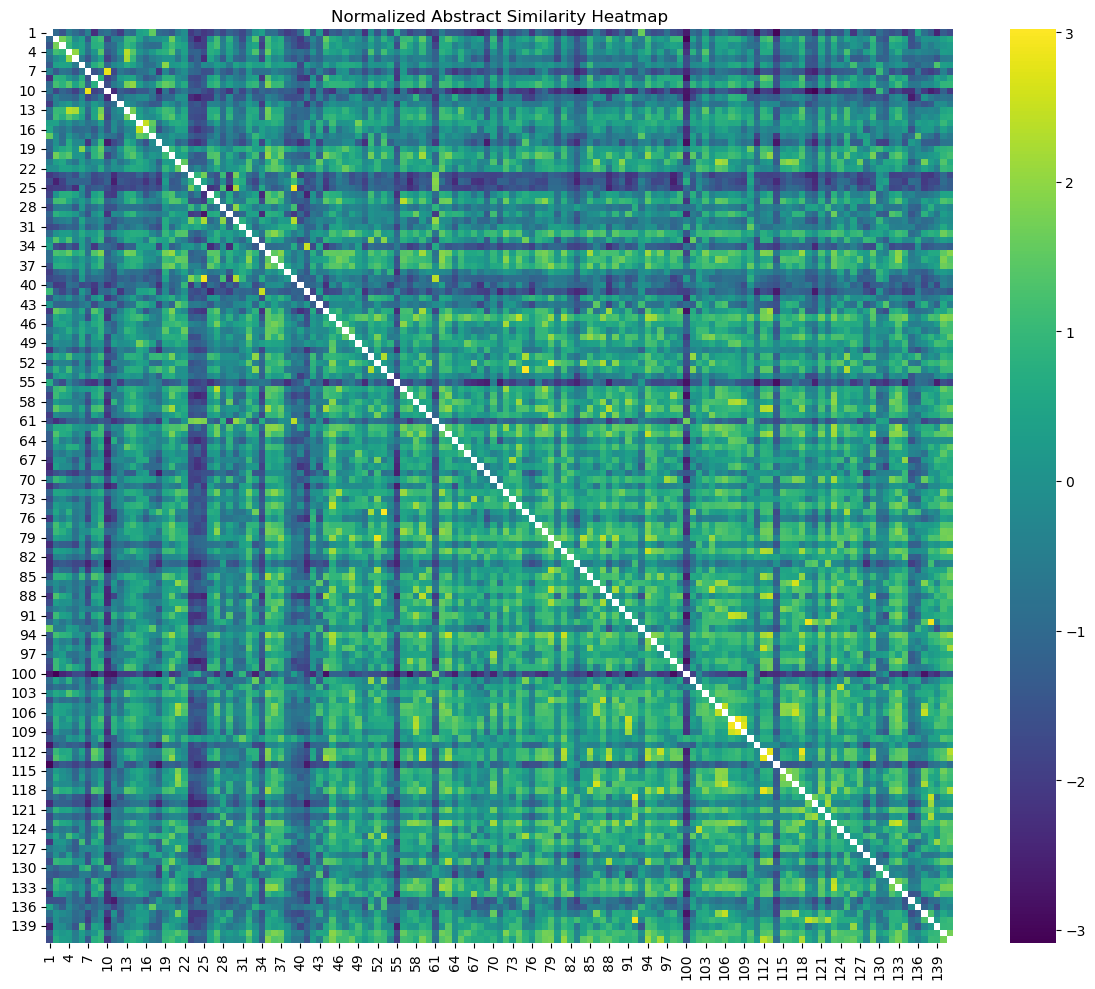

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create heatmap with normalized values
plt.figure(figsize=(12, 10))
sns.heatmap(normalized_similarity_df, cmap='viridis')
plt.title('Normalized Abstract Similarity Heatmap')
plt.tight_layout()
plt.show()